In [1]:
import datetime
import datetime as dt

import numpy as np
from matplotlib import pyplot as plt
from netCDF4 import Dataset
import pandas as pd
from scipy.optimize import minimize

from xcube.core.store import new_data_store

In [2]:
fsd = new_data_store("file", root="output_ebro")

In [3]:
fsd.list_data_ids()

['irrigation_input_final.zarr',
 'irrigation_input.zarr',
 'calibratedv1.zarr',
 'soil_moisture_filled.zarr',
 'irrigation_input_masked_ebro_basin.zarr']

In [4]:
irr_input = fsd.open_data("irrigation_input.zarr")

In [5]:
irr_input

<xarray.Dataset> Size: 381MB
Dimensions:        (time: 31, lat: 320, lon: 736)
Coordinates:
  * lat            (lat) float64 3kB 43.19 43.18 43.17 ... 40.36 40.35 40.34
  * lon            (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    crs            (time, lat, lon) |S8 58MB dask.array<chunksize=(8, 80, 184), meta=np.ndarray>
    lc_binary      (lat, lon) float32 942kB dask.array<chunksize=(320, 736), meta=np.ndarray>
    pev            (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sf             (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    ssm            (time, lat, lon) float64 58MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 58MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    stl1           (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    tp             (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    date_modified:              2025-08-26T16:57:23.226724
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    ...                         ...
    region_name:                CEURO
    sensor:                     CSAR
    source:                     Derived from EO radar observations
    time_coverage_end:          2020-01-01T23:59:59Z
    time_coverage_start:        2020-01-01T00:00:00Z
    title:                      Daily Surface Soil Moisture 1km: CEURO 2020-0...

In [6]:

#CALIBRATION
def sm_inversion(sm, et, a, b, z, RF, thr=None): 
    """Evotranspiration and Soil moisture to irrigation"""
    # sm - soil moisture
    # et - evotranspiration
    # a/b - drainage parameter
    # z - soil water capacity
    # f/RF - Adjusting factor
    p_sim = z * (sm[1:] - sm[:-1]) + ((a * sm[1:]**b + a * sm[:-1]**b) / 2.) +  ((RF * sm[1:] * et[1:] + RF * sm[:-1] * et[:-1]) / 2.)

    p_sim[abs(np.diff(sm))<=0.001]=0.0
    p_sim[p_sim < 1.0]=0.0   # 2mm/day for NN=4 -> 0.5

    return np.clip(p_sim, 0, thr)

def calib_sm_inversion(sm,  p_obs, et, NN,   x0=None, bounds=None, options=None, method='TNC'): 


    if x0 is None:
        x0 = np.array([20., 5., 80,1.])

    if bounds is None:
        bounds = ((0,200), (0.01, 50), (1, 800), (0.1,1.4))

    if options is None:
        options = {'ftol': 1e-8, 'maxiter': 4000, 'disp': False}

#    if options is None:
#        options = {'ftol': 1e-8, 'maxiter': 3000, 'disp': False}


    result = minimize(cost_fun, x0, args=(sm,  p_obs, et, NN),method=method, bounds=bounds, options=options)

    a, b, z,RF = result.x

    return a, b, z, RF


def cost_fun(x0, sm,  p_obs, et, NN):

    # The following args are 1D time-series
    p_sim = sm_inversion(sm, et, x0[0], x0[1], x0[2],x0[3])
    p_obs = p_obs[:-1]
    p_sim[np.isnan(p_obs)] = np.nan
    p_sim1 = np.add.reduceat(p_sim[np.isfinite(p_sim)], np.arange(0, len(p_sim[np.isfinite(p_sim)]), NN))
    p_obs1 = np.add.reduceat(p_obs[np.isfinite(p_sim)], np.arange(0, len(p_obs[np.isfinite(p_sim)]), NN))
    rmsd = np.nanmean((p_obs1 - p_sim1)**2)**0.5

    return rmsd


The calibration function expects a 1D array of single pixel time-series for soil moisture, evotranspiration and rainfall.

Define irrigation season
- may to september (will be refined later)
- dataset that will be published will contain those months and 0 for others - aggregated at 1 or 2 weeks
- from jan-may and sep-dec per year, we take all days for calibration.
- then inside the range may-sep, we also calibrate where rainfall < 1mm pixel-wise
- then based on the calibrated values, we calculate the IWU for may-sep

- create a new empty dataset with same dims lat, lon
- 

In [7]:
def calib_wrapper(sm_ts, p_obs_ts, et_ts, NN):
    if np.isnan(np.nanmean(sm_ts)):
        return np.array([np.nan, np.nan, np.nan, np.nan])

    a, b, z, RF = calib_sm_inversion(sm_ts, p_obs_ts, et_ts, NN)
    return np.array([a, b, z, RF])

In [8]:
from xcube.core.chunk import chunk_dataset

In [9]:
ds = chunk_dataset(irr_input, chunk_sizes={"time":-1, "lat":128, "lon":128}, format_name="zarr")
ds

<xarray.Dataset> Size: 381MB
Dimensions:        (time: 31, lat: 320, lon: 736)
Coordinates:
  * lat            (lat) float64 3kB 43.19 43.18 43.17 ... 40.36 40.35 40.34
  * lon            (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    crs            (time, lat, lon) |S8 58MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    lc_binary      (lat, lon) float32 942kB dask.array<chunksize=(128, 128), meta=np.ndarray>
    pev            (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sf             (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm            (time, lat, lon) float64 58MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 58MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    stl1           (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    tp             (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    date_modified:              2025-08-26T16:57:23.226724
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    ...                         ...
    region_name:                CEURO
    sensor:                     CSAR
    source:                     Derived from EO radar observations
    time_coverage_end:          2020-01-01T23:59:59Z
    time_coverage_start:        2020-01-01T00:00:00Z
    title:                      Daily Surface Soil Moisture 1km: CEURO 2020-0...

In [10]:
import xarray as xr
import numpy as np
import pandas as pd
result = xr.apply_ufunc(
    calib_wrapper,
    ds["SWI"],      
    ds["tp"],    
    ds["pev"],       
    7,           
    input_core_dims=[["time"], ["time"], ["time"], []],  
    output_core_dims=[["params"]],  
    vectorize=True,                 
    dask="parallelized",           
    output_dtypes=[float],
    output_sizes={"params": 4}
)

/tmp/ipykernel_460880/1423832544.py:4: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  result = xr.apply_ufunc(


In [11]:
result

<xarray.DataArray (lat: 320, lon: 736, params: 4)> Size: 8MB
dask.array<transpose, shape=(320, 736, 4), dtype=float64, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
    number       int64 8B 0
    spatial_ref  int64 8B 0
Dimensions without coordinates: params

In [12]:
from dask.distributed import Client, LocalCluster
import xarray as xr

cluster = LocalCluster(n_workers=12, threads_per_worker=1)
client = Client(cluster)
print(client)

<Client: 'tcp://127.0.0.1:37101' processes=12 threads=12, memory=30.12 GiB>


In [13]:
%%time
ds_calib = result.compute()

/tmp/ipykernel_460880/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_460880/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_460880/2083791450.py:32: OptimizeWarning: Unknown solver options: maxiter
/tmp/ipykernel_460880/2083791450.py:32: OptimizeWarning: Unknown solver options: maxiter
/tmp/ipykernel_460880/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_460880/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_460880/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_460880/2083791450.py:32: OptimizeWarning: Unknown solver options: maxiter
/tmp/ipykernel_460880/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_460880/2083791450.py:32: OptimizeWarning: Unknown solver options: maxiter
/tmp/ipykernel_460880/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_460880/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_460880/2496137942.py:2: Runti

CPU times: user 2min 55s, sys: 40.8 s, total: 3min 36s
Wall time: 16min 42s


In [14]:
ds_calib

<xarray.DataArray (lat: 320, lon: 736, params: 4)> Size: 8MB
array([[[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]]], shape=(320, 736, 4))
Coordinates:
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
    number       int64 8B 0
    spatial_ref  int64 8B 0
Dimensions without coordinates: params

In [15]:
client.shutdown()

In [16]:
ds["calibration"] = ds_calib

In [17]:
ds

<xarray.Dataset> Size: 388MB
Dimensions:        (time: 31, lat: 320, lon: 736, params: 4)
Coordinates:
  * lat            (lat) float64 3kB 43.19 43.18 43.17 ... 40.36 40.35 40.34
  * lon            (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Dimensions without coordinates: params
Data variables:
    SWI            (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    crs            (time, lat, lon) |S8 58MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    lc_binary      (lat, lon) float32 942kB dask.array<chunksize=(128, 128), meta=np.ndarray>
    pev            (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sf             (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm            (time, lat, lon) float64 58MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 58MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    stl1           (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    tp             (time, lat, lon) float32 29MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    calibration    (lat, lon, params) float64 8MB nan nan nan ... nan nan nan
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    date_modified:              2025-08-26T16:57:23.226724
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    ...                         ...
    region_name:                CEURO
    sensor:                     CSAR
    source:                     Derived from EO radar observations
    time_coverage_end:          2020-01-01T23:59:59Z
    time_coverage_start:        2020-01-01T00:00:00Z
    title:                      Daily Surface Soil Moisture 1km: CEURO 2020-0...

In [18]:
fsd.write_data(ds_calib.to_dataset(name="calibration"), "calibratedv2.zarr")

'calibratedv2.zarr'

In [19]:
calibrated = fsd.open_data("calibratedv2.zarr")

In [20]:
calibrated

<xarray.Dataset> Size: 8MB
Dimensions:      (lat: 320, lon: 736, params: 4)
Coordinates:
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
    number       int64 8B ...
    spatial_ref  int64 8B ...
Dimensions without coordinates: params
Data variables:
    calibration  (lat, lon, params) float64 8MB dask.array<chunksize=(80, 368, 2), meta=np.ndarray>

In [21]:
calibrated.calibration.values.shape

(320, 736, 4)

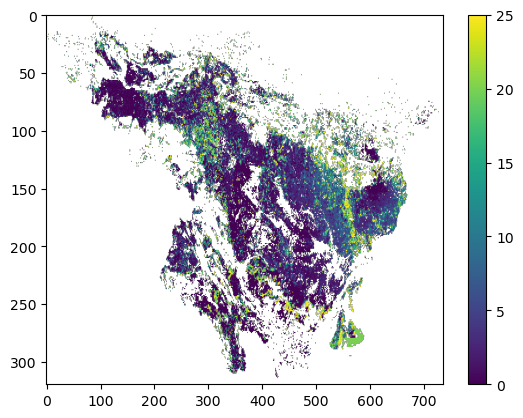

In [22]:
plt.imshow(calibrated.calibration.values[:,:,0], cmap="viridis", aspect="auto", vmin=0, vmax=25)
plt.colorbar()
plt.show()

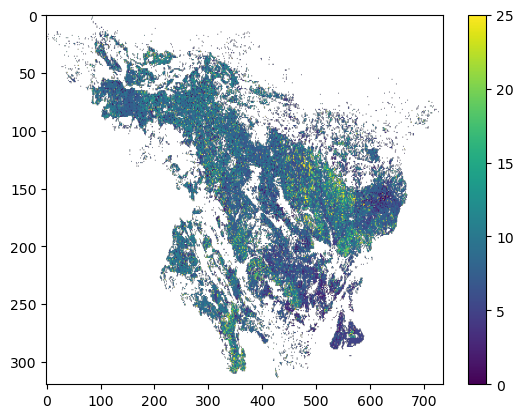

In [26]:
plt.imshow(calibrated.calibration.values[:,:,1], cmap="viridis", aspect="auto", vmin=0, vmax=25)
plt.colorbar()
plt.show()

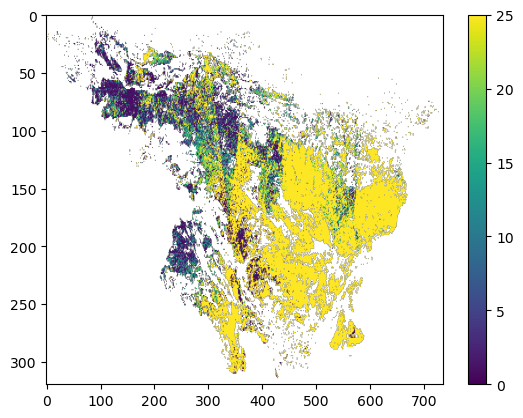

In [27]:
plt.imshow(calibrated.calibration.values[:,:,2], cmap="viridis", aspect="auto", vmin=0, vmax=25)
plt.colorbar()
plt.show()

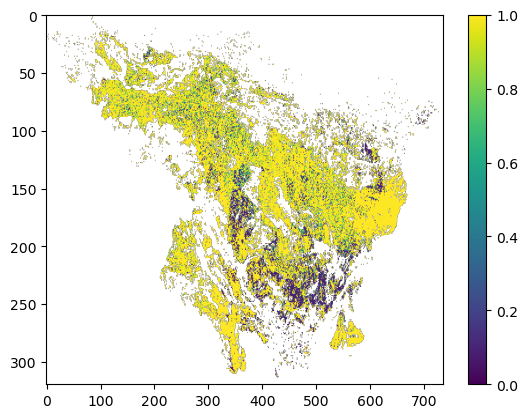

In [34]:
plt.imshow(calibrated.calibration.values[:,:,3], cmap="viridis", aspect="auto", vmin=0, vmax=1)
plt.colorbar()
plt.show()

In [23]:
arr_reshaped = calibrated.calibration.values.reshape(-1, 4)

In [24]:
unique_param_sets = np.unique(arr_reshaped, axis=0)

print(f"Number of unique parameter sets: {len(unique_param_sets)}")
print(unique_param_sets)

Number of unique parameter sets: 234503
[[0.         0.01       1.         0.1       ]
 [0.         0.01       1.         0.12350188]
 [0.         0.01       1.         0.1711377 ]
 ...
 [       nan        nan        nan        nan]
 [       nan        nan        nan        nan]
 [       nan        nan        nan        nan]]


In [25]:
unique_param_sets_no_nan = unique_param_sets[~np.isnan(unique_param_sets).any(axis=1)]
print(f"Unique parameter sets without NaNs: {len(unique_param_sets_no_nan)}")
print(unique_param_sets_no_nan)

Unique parameter sets without NaNs: 55356
[[0.00000000e+00 1.00000000e-02 1.00000000e+00 1.00000000e-01]
 [0.00000000e+00 1.00000000e-02 1.00000000e+00 1.23501880e-01]
 [0.00000000e+00 1.00000000e-02 1.00000000e+00 1.71137699e-01]
 ...
 [2.00000000e+02 4.15329200e+01 4.20803572e+01 8.10442611e-01]
 [2.00000000e+02 4.21250797e+01 4.07591677e+00 1.39200537e+00]
 [2.00000000e+02 4.99991447e+01 1.51336085e+01 1.40000000e+00]]
